### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import mlflow
import logging
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.autograd import Variable
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.dice_score import dice_loss, dice_coeff
from utils.evaluate import evaluate
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.21 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
exp_run_id = f'acdc_feedback_resunet_img_slices_with_ratios_v4{datetime.now().strftime("%Y%m%d%H%M%S")}'
log_file_name = f'./logs/{exp_run_id}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [4]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-segmentation-of-ventricular-structures-and-myocardium")

2024/11/14 21:50:48 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1301949192404675', creation_time=1726678925784, experiment_id='1301949192404675', last_update_time=1731601111962, lifecycle_stage='active', name='/cmri-segmentation-of-ventricular-structures-and-myocardium', tags={'mlflow.experiment.sourceName': '/cmri-segmentation-of-ventricular-structures-and-myocardium',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [5]:
dir_checkpoint = Path('./models/checkpoints/feedback_resunet_img_slices_with_ratios_v4/')

epochs = 10
batch_size = 4
lr = 1e-5
scale = 1
amp = False

### Data Loading

In [6]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation')
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


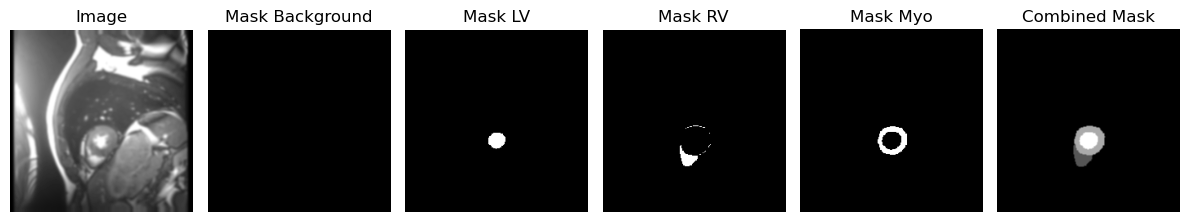

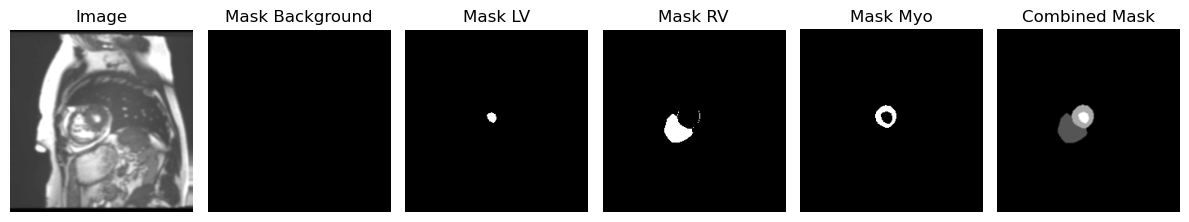

In [7]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    image = sample['image'][i].squeeze().numpy()  # Convert to numpy array
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 6, figsize=(12, 5))

    # Plot the image and masks
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(msk_bkg, cmap='gray')
    axes[1].set_title('Mask Background')
    axes[1].axis('off')

    axes[2].imshow(msk_lv, cmap='gray')
    axes[2].set_title('Mask LV')
    axes[2].axis('off')

    axes[3].imshow(msk_rv, cmap='gray')
    axes[3].set_title('Mask RV')
    axes[3].axis('off')

    axes[4].imshow(msk_myo, cmap='gray')
    axes[4].set_title('Mask Myo')
    axes[4].axis('off')

    axes[5].imshow(msk_all, cmap='gray')
    axes[5].set_title('Combined Mask')
    axes[5].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

#### Feedback ResUNet

In [8]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size):
        super(ConvLSTMCell, self).__init__()
        padding = kernel_size // 2  # Calculate padding to maintain spatial dimensions
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels
        self.kernel_size = kernel_size

        # Convolution to compute input, forget, output, and cell gates
        self.conv = nn.Conv2d(input_channels + hidden_channels, 4 * hidden_channels, kernel_size, padding=padding)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state  # Current hidden and cell states

        # Concatenate input and hidden state along the channel dimension
        combined = torch.cat([input_tensor, h_cur], dim=1)  # concatenate along channel axis
        combined_conv = self.conv(combined)  # Apply convolution
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_channels, dim=1)  # Split into gates
        
        # Apply activations for input, forget, output, and cell gates
        i = torch.sigmoid(cc_i)  # Input gate
        f = torch.sigmoid(cc_f)  # Forget gate
        o = torch.sigmoid(cc_o)  # Output gate
        g = torch.tanh(cc_g)  # Cell gate

        # Compute next cell and hidden states
        c_next = f * c_cur + i * g  # Update cell state
        h_next = o * torch.tanh(c_next)  # Update hidden state

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        # Initialize hidden and cell states with zeros
        return (Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda(),
                Variable(torch.zeros(batch_size, self.hidden_channels, height, width)).cuda())

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        # self.bn1 = nn.BatchNorm2d(out_channels)
        self.gn1 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        # self.bn2 = nn.BatchNorm2d(out_channels)
        self.gn2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
        else:
            self.residual_conv = None

    def forward(self, x):
        residual = x
        if self.residual_conv:
            residual = self.residual_conv(x)
        out = self.conv1(x)
        # out = self.bn1(out)
        out = self.gn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        # out = self.bn2(out)
        out = self.gn2(out)
        out += residual
        out = self.relu(out)
        return out

class FeedbackResUNet(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(FeedbackResUNet, self).__init__()
        self.n_channels = input_channels
        self.n_classes = num_classes
        self.bilinear = False

        # Encoder
        self.resblock1 = ResidualBlock(input_channels, 64)
        self.resblock2 = ResidualBlock(64, 128)
        self.resblock3 = ResidualBlock(128, 256)
        self.resblock4 = ResidualBlock(256, 512)

        # Bottleneck
        self.resblock_bottleneck = ResidualBlock(512, 1024)

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # Upsampling layer
        self.resblock5 = ResidualBlock(1024, 512)

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # Second upsampling layer
        self.resblock6 = ResidualBlock(512, 256)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # Third upsampling layer
        self.resblock7 = ResidualBlock(256, 128)

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # Fourth upsampling layer
        self.resblock8 = ResidualBlock(128, 64)

        # Final output
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)  # 1x1 convolution to produce output masks
        
        # Adjust channels for feedback
        self.adjust_channels = nn.Conv2d(num_classes, input_channels, kernel_size=1)

    def forward(self, x):
        batch_size, _, height, width = x.size()

        # First round - Encoder
        x1 = self.resblock1(x)
        x1_pooled = F.max_pool2d(x1, kernel_size=2)  # Downsample with max pooling

        x2 = self.resblock2(x1_pooled)
        x2_pooled = F.max_pool2d(x2, kernel_size=2)  # Downsample with max pooling

        x3 = self.resblock3(x2_pooled)
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = self.resblock4(x3_pooled)
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        x_b = self.resblock_bottleneck(x4_pooled)

        # Decoder
        x5 = self.upconv1(x_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = self.resblock5(x5)

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = self.resblock6(x6)

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        x7 = self.resblock7(x7)

        x8 = self.upconv4(x7)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        x8 = self.resblock8(x8)

        # Final output of the first round
        out1 = self.final_conv(x8)  # Apply final 1x1 convolution to produce output masks
        
        # Second round - Feedback the output of the first round into the encoder
        adjusted_out1 = self.adjust_channels(out1)  # Adjust channels of out1 to match input channels
        feedback_input = x + adjusted_out1  # Add input and adjusted output of the first round

        # Second round - Feedback the output of the first round into the encoder
        x1 = self.resblock1(feedback_input)
        x1_pooled = F.max_pool2d(x1, kernel_size=2)  # Downsample with max pooling

        x2 = self.resblock2(x1_pooled)
        x2_pooled = F.max_pool2d(x2, kernel_size=2)  # Downsample with max pooling

        x3 = self.resblock3(x2_pooled)
        x3_pooled = F.max_pool2d(x3, kernel_size=2)  # Downsample with max pooling

        x4 = self.resblock4(x3_pooled)
        x4_pooled = F.max_pool2d(x4, kernel_size=2)  # Downsample with max pooling

        # Bottleneck
        x_b = self.resblock_bottleneck(x4_pooled)

        # Decoder
        x5 = self.upconv1(x_b)  # Upsample the bottleneck output
        x5 = F.pad(x5, (0, x4.size(3) - x5.size(3), 0, x4.size(2) - x5.size(2)))  # Pad to match the encoder feature map size
        x5 = torch.cat([x5, x4], dim=1)  # Concatenate with corresponding encoder output
        x5 = self.resblock5(x5)

        x6 = self.upconv2(x5)  # Upsample
        x6 = F.pad(x6, (0, x3.size(3) - x6.size(3), 0, x3.size(2) - x6.size(2)))  # Pad to match the encoder feature map size
        x6 = torch.cat([x6, x3], dim=1)  # Concatenate with corresponding encoder output
        x6 = self.resblock6(x6)

        x7 = self.upconv3(x6)  # Upsample
        x7 = F.pad(x7, (0, x2.size(3) - x7.size(3), 0, x2.size(2) - x7.size(2)))  # Pad to match the encoder feature map size
        x7 = torch.cat([x7, x2], dim=1)  # Concatenate with corresponding encoder output
        x7 = self.resblock7(x7)

        x8 = self.upconv4(x7)  # Upsample
        x8 = F.pad(x8, (0, x1.size(3) - x8.size(3), 0, x1.size(2) - x8.size(2)))  # Pad to match the encoder feature map size
        x8 = torch.cat([x8, x1], dim=1)  # Concatenate with corresponding encoder output
        x8 = self.resblock8(x8)

        # Final output of the second round
        out2 = self.final_conv(x8)  # Apply final 1x1 convolution to produce output masks

        return out2

### Model Training

In [9]:
def train_model(
        model,
        device,
        epochs: int = 5,
        start_epoch: int = 1,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
        exp_run_id: str = None,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)

    # Start an MLflow run
    with mlflow.start_run() as run:
        # Get the run_id of the current active run
        run_id = run.info.run_id

        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Images scaling:  {img_scale}
            Mixed Precision: {amp}
        ''')

        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'img_scale': img_scale,
            'mixed_precision': amp
        }

        mlflow.log_params(params)

        # Initialize TensorBoard writer
        writer = SummaryWriter(log_dir=f'./logs/tensorboard_runs/{exp_run_id}')  # This will save logs in '/logs/tensorboard_runs/{exp_run_id}'

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        # criterion = nn.BCELoss() if model.n_classes > 1 else nn.BCEWithLogitsLoss() # nn.CrossEntropyLoss()
        criterion = nn.BCEWithLogitsLoss()
        global_step = 0

        # Begin training
        for epoch in range(start_epoch, epochs + 1):
            model.train()
            epoch_loss = 0
            epoch_dice_loss = 0
            running_val_dice_loss = 0
            running_val_dice_loss_steps = 0

            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    # images, msks_lv, msks_rv, msks_myo = batch['image'], batch['mask_lv'], batch['mask_rv'], batch['mask_myo']
                    images, masks, masks_all = batch['image'], batch['masks'], batch['masks_all']
                    images = images.permute(0, 3, 1, 2)
                    # masks_all = torch.argmax(masks_all, dim=1)
                    masks_all = masks_all.permute(0, 3, 1, 2)
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")

                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'

                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_masks = masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    # true_masks = masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        # masks_pred = model(images).permute(1, 0, 2, 3)
                        masks_pred = model(images)
                        # logging.info(f"masks pred shape: {masks_pred.shape}")
                        if model.n_classes == 1:
                            loss_ce = criterion(masks_pred.squeeze(1), true_masks.float())
                            loss_dice = dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                            loss = 0.3 * loss_ce + 0.7 * loss_dice
                        else:
                            loss_ce = criterion(masks_pred, true_masks)  # true_masks.squeeze(1).long()
                            loss_dice = dice_loss(
                                # masks_pred,
                                # true_masks,
                                # F.softmax(masks_pred, dim=1).float(),
                                F.sigmoid(masks_pred > 0.5).float(),
                                true_masks.float(),
                                # F.softmax(masks_pred, dim=1).float(),
                                # F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                multiclass=True
                            )
                            loss = 0.3 * loss_ce + 0.7 * loss_dice

                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()

                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    epoch_dice_loss += loss_dice.item()
                    # pbar.set_postfix(**{'loss (batch)': loss.item()})
                    pbar.set_postfix(**{'total_loss (batch)': loss.item(), 'dice_loss (batch)': loss_dice.item(), 'bce_loss (batch)': loss_ce.item()})

                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_score = evaluate(model, val_dataloader, device, amp)
                            running_val_dice_loss += 1 - val_score
                            running_val_dice_loss_steps += 1
                            scheduler.step(val_score)
                            logging.info('Validation Dice score: {}'.format(val_score))

            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')

            # Log metrics to TensorBoard
            avg_loss = epoch_loss / len(train_dataloader)
            avg_dice_loss = epoch_dice_loss / len(train_dataloader)
            avg_dice_val_loss = running_val_dice_loss / running_val_dice_loss_steps
            writer.add_scalar("Training Combined Loss", avg_loss, epoch)
            writer.add_scalars("Training vs. Validation Dice Loss",
                              {'Training': avg_dice_loss, 'Validation': avg_dice_val_loss},
                              epoch)            

        # Flush and close the writer when done
        writer.flush()
        writer.close()

        '''
        # Log train, validation and test set Dice Scores
        train_dice_score = evaluate(model, train_dataloader, device, amp).item()
        val_dice_score = evaluate(model, val_dataloader, device, amp).item()
        test_dice_score = evaluate(model, test_dataloader, device, amp).item()

        mlflow.log_metric("train_dice_score", round(train_dice_score, 4))
        mlflow.log_metric("val_dice_score", round(val_dice_score, 4))
        mlflow.log_metric("test_dice_score", round(test_dice_score, 4))

        logging.info(f'Overall Train Set Dice score: {round(train_dice_score, 4)}')
        logging.info(f'Overall Validation Set Dice score: {round(val_dice_score, 4)}')
        logging.info(f'Overall Test Dice Set score: {round(test_dice_score, 4)}')
        '''

    return run_id

### Training

In [10]:
# Weight Initialization
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [11]:
# n_channels=3 for RGB images
# n_classes is the number of probabilities you want to get per pixel
model = FeedbackResUNet(input_channels=1, num_classes=4)

# Use checkpoints to train
use_checkpoints = False

if use_checkpoints:
    checkpoint_epoch = 1
    checkpoint_path = str(dir_checkpoint / f'checkpoint_epoch{checkpoint_epoch}.pth')
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint)
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint_epoch + 1
else:
    start_epoch = 1
    model.apply(weights_init)

model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

model.to(device=device)

try:
    run_id = train_model(
        model=model,
        epochs=epochs,
        start_epoch=start_epoch,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )

Epoch 10/10: 100%|██████████| 16000/16000 [1:11:58<00:00,  3.70img/s, bce_loss (batch)=0.00433, dice_loss (batch)=0.97, total_loss (batch)=0.68]


### Testing and Evaluation

In [ ]:
'''
# Model Evaluation Using a Checkpoint
model = FeedbackResUNet(input_channels=1, num_classes=4)

# Load the state dict from the checkpoint
checkpoint_dir = Path('./models/checkpoints/feedback_resunet_img_slices_with_ratios_v4/')
checkpoint = torch.load(str(checkpoint_dir / 'checkpoint_epoch{}.pth'.format('5')))
model.load_state_dict(checkpoint)
model = model.to(device)
'''

In [12]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0, n_classes=4, combined_mask=True):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                true_masks_all = sample['masks_all']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                print(f'combined true masks shape: {true_masks_all.shape}')
                images = images.permute(0, 3, 1, 2)
                true_masks_all = true_masks_all.permute(0, 3, 1, 2)

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks_all = true_masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = (true_masks * 255).round().long()
                true_masks_all = (true_masks_all * 255).round().long()

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                # preds = torch.sigmoid(outputs)
                preds = (outputs > 0.5).float()  # Convert to binary masks (0 or 1)
                # preds = preds.float().cpu().numpy().squeeze(1)

                # Convert logits to predicted class labels
                # preds = torch.argmax(outputs, dim=1).long()

                image = images[img_idx].cpu().squeeze()
                true_mask_all = true_masks_all[img_idx].cpu().squeeze().numpy()
                true_mask_bkg = true_masks[img_idx][0].cpu().squeeze().numpy()
                true_mask_lv = true_masks[img_idx][1].cpu().squeeze().numpy()
                true_mask_rv = true_masks[img_idx][2].cpu().squeeze().numpy()
                true_mask_myo = true_masks[img_idx][3].cpu().squeeze().numpy()

                # Apply argmax to get the class with the highest probability for each pixel
                pred_mask_all = None
                # pred_mask_all = torch.argmax(preds[img_idx], dim=0).cpu().numpy()  # Shape: (height, width)
                # pred_mask_all = preds[img_idx].cpu().numpy()

                print(f'preds shape: {preds.shape}')
                print(f'True mask unique values: {np.unique(true_mask_all)}')
                # print(f'Pred mask unique values: {np.unique(pred_mask_all)}')

                if n_classes > 1 and combined_mask:
                    fig, ax = plt.subplots(1, 6, figsize=(16, 5))
                    ax[0].imshow(image, cmap='gray')
                    ax[0].set_title('Input Image')

                    ax[1].imshow(true_mask_lv, cmap='gray')
                    ax[1].set_title('True LV')

                    ax[2].imshow(true_mask_rv, cmap='gray')
                    ax[2].set_title('True RV')

                    ax[3].imshow(true_mask_myo, cmap='gray')
                    ax[3].set_title('True MYO')

                    ax[4].imshow(true_mask_all, cmap='gray')
                    ax[4].set_title('True Mask')

                    ax[5].imshow(pred_mask_all, cmap='gray')
                    ax[5].set_title('Predicted Mask')
                elif n_classes > 1 and not combined_mask:
                    fig, ax = plt.subplots(2, 5, figsize=(15, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_bkg, cmap='gray')
                    ax[0][1].set_title('True Background')

                    ax[0][2].imshow(true_mask_lv, cmap='gray')
                    ax[0][2].set_title('True LV')

                    ax[0][3].imshow(true_mask_rv, cmap='gray')
                    ax[0][3].set_title('True RV')

                    ax[0][4].imshow(true_mask_myo, cmap='gray')
                    ax[0][4].set_title('True MYO')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(preds[img_idx][0].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][1].set_title('Pred Background')

                    ax[1][2].imshow(preds[img_idx][1].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][2].set_title('Pred LV')

                    ax[1][3].imshow(preds[img_idx][2].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][3].set_title('Pred RV')

                    ax[1][4].imshow(preds[img_idx][3].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][4].set_title('Pred MYO')
                else:
                    print(f'Image: {torch.unique(images[img_idx])}')
                    print(f'True Mask: {torch.unique(true_masks_all[img_idx])}')
                    print(f'Pred Mask: {np.unique(preds[img_idx])}')

                    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_all, cmap='gray')
                    ax[0][1].set_title('True Mask')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(pred_mask_all, cmap='gray')
                    ax[1][1].set_title('Predicted Mask')

                plt.show()
                break  # Visualize only one image
            else:
                continue

images shape: torch.Size([4, 224, 224, 1])
true masks shape: torch.Size([4, 4, 224, 224])
combined true masks shape: torch.Size([4, 224, 224, 1])
preds shape: torch.Size([4, 4, 224, 224])
True mask unique values: [  0 170 255]


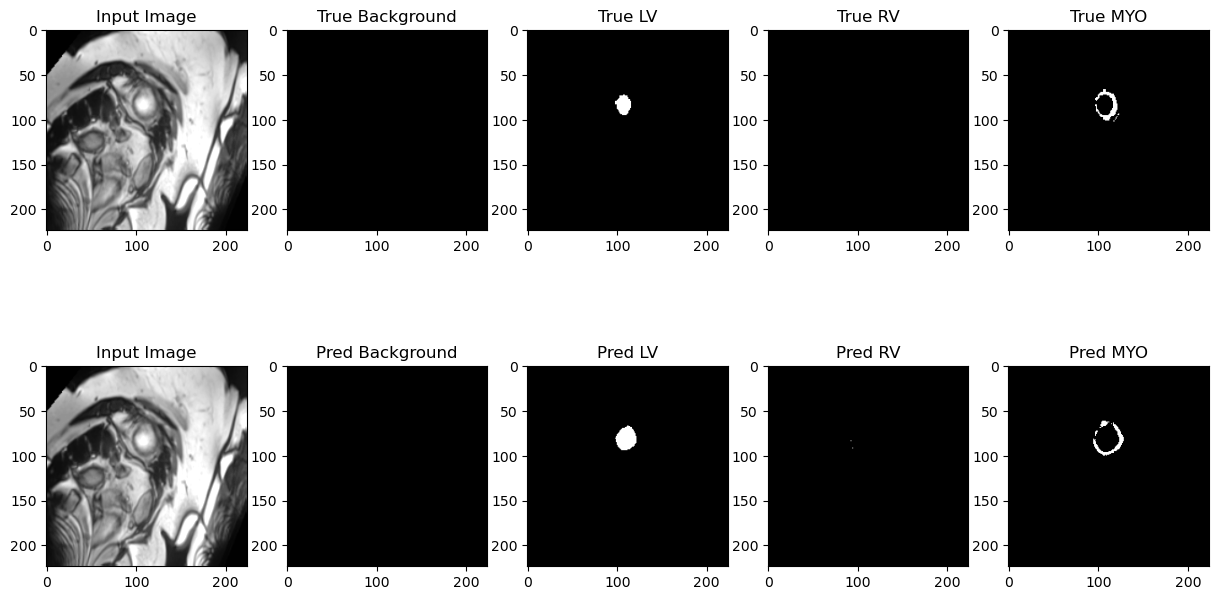

In [13]:
visualize_prediction(model, test_dataloader, device, sample_idx=1, img_idx = 3, n_classes=4, combined_mask=False)

In [ ]:
# torch.cuda.empty_cache()

### Model Evaluation

In [14]:
# Function to calculate Dice score for a single class
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    sets_sum = pred.sum() + target.sum()
    sets_sum = torch.where(sets_sum == 0, intersection, sets_sum)
    dice = (2. * intersection + smooth) / (sets_sum + smooth)
    return dice


# Function to evaluate Dice score for each class in the test set
def evaluate_dice_score(model, dataloader, num_classes=4, device='cpu', threshold=0.5):
    model.eval()  # Set model to evaluation mode
    dice_scores = [0.0] * num_classes  # List to store Dice score for each class
    # count = 0  # Number of samples
    batch_count = len(dataloader) # Number of batches

    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            # Extract data from the sample
            images = sample['image']
            true_masks = sample['masks']
            true_masks_all = sample['masks_all']
            # print(f'images shape: {images.shape}')
            # print(f'true masks shape: {true_masks.shape}')
            # print(f'combined true masks shape: {true_masks_all.shape}')
            images = images.permute(0, 3, 1, 2)
            true_masks_all = true_masks_all.permute(0, 3, 1, 2)

            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

            outputs = model(images)  # Shape: (batch_size, 4, height, width)
            # outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities

            # Binarize outputs based on threshold
            # predictions = (outputs > threshold).float()  # Shape: (batch_size, 4, height, width)
            predictions = (F.sigmoid(outputs) > threshold).float()

            # Calculate Dice score for each class
            for i in range(num_classes):  # Loop over each class
                dice_scores[i] += dice_coeff(
                    predictions[:, i, :, :].flatten(0, 1),
                    true_masks[:, i, :, :].flatten(0, 1),
                    reduce_batch_first=False
                    )
                '''
                dice_scores[i] += dice_score(
                    predictions[:, i, :, :],
                    true_masks[:, i, :, :]
                    )
                '''

            # count += images.size(0)  # Update sample count
            # batch_count += 1 # Update batch count

    # Average Dice scores across the dataset
    # avg_dice_scores = [score / count for score in dice_scores]
    avg_dice_scores_batch = [score / batch_count for score in dice_scores]
    return avg_dice_scores_batch

In [15]:
# run_id = "74fa318220bd4e988b801717b3e193e2"

with mlflow.start_run(run_id=run_id):
    # Compute the Dice score for each class in the Train set
    avg_dice_scores_batch = evaluate_dice_score(model, train_dataloader, device=device)
    print("Dice Scores - Train Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("train_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("train_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("train_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("train_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("train_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Validation set
    avg_dice_scores_batch = evaluate_dice_score(model, val_dataloader, device=device)
    print("\nDice Scores - Validation Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("val_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("val_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("val_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("val_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("val_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Test set
    avg_dice_scores_batch = evaluate_dice_score(model, test_dataloader, device=device)
    print("\nDice Scores - Test Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("test_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("test_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("test_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("test_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("test_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))

Dice Scores - Train Set:
BKG: 1.0000	LV: 0.9603	RV: 0.9119	MYO: 0.8880	OVR: 0.9201

Dice Scores - Validation Set:
BKG: 1.0000	LV: 0.9059	RV: 0.8090	MYO: 0.7569	OVR: 0.8239

Dice Scores - Test Set:
BKG: 1.0000	LV: 0.9027	RV: 0.7965	MYO: 0.7673	OVR: 0.8222
